This is a [Google Colaboratory](https://colab.research.google.com/notebooks/welcome.ipynb) notebook file. Python programs are run directly in the browser—a great way to learn and use PyTorch. To follow this tutorial, run the notebook in Google Colab by clicking the button at the top of this page.

1. In Colab, connect to a Python runtime: At the top-right of the menu bar, select *CONNECT*.
2. Run all the notebook code cells: Select *Runtime* > *Run all*.

The goal is to inject a patch backdoor. After completion, download the ipynb and submit it to canvas.


In [1]:
# --- 1. Setup ---
# Install PyTorch (Colab usually has it preinstalled)
!pip install torch torchvision torchaudio --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.8.0+cu126
CUDA available: True


In [2]:
# --- 2. Tensors ---
# Create some tensors
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
y = torch.ones_like(x)

print("x:\n", x)
print("y:\n", y)
print("x + y =\n", x + y)
print("x * y =\n", x * y)

# Move tensor to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
x = x.to(device)
print(f"x is on {x.device}")

# --- 3. Gradients & Autograd ---
x = torch.randn(3, requires_grad=True)
y = x ** 2
z = y.sum()
z.backward()  # Compute gradients
print("x:", x)
print("x.grad:", x.grad)

x:
 tensor([[1., 2.],
        [3., 4.]])
y:
 tensor([[1., 1.],
        [1., 1.]])
x + y =
 tensor([[2., 3.],
        [4., 5.]])
x * y =
 tensor([[1., 2.],
        [3., 4.]])
x is on cuda:0
x: tensor([ 0.3529, -0.0785, -0.8944], requires_grad=True)
x.grad: tensor([ 0.7058, -0.1569, -1.7888])


In [10]:
# --- 4. Simple Neural Network (MNIST) ---
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

def denormalize(image):
    return image * 0.5 + 0.5

def add_trigger(images):
    # add a small white 3 x 3 square to the left top corner
    images = images.clone()
    images[..., :3, :3] = 1
    return images


trainset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

backdoor_target = 0
poison_rate = 0.1
# every batch has 64 images, so selecting 10% of images from each batch.
num_poison = int(poison_rate*64)


# --- 5. Training Loop (backdoor+clean) ---
epochs = 10  # Increase to 5+ for better accuracy
for epoch in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        # Add backdoor injection
        random_indices = torch.randint(0, images.size(0), (num_poison,))
        images[random_indices] = add_trigger(images[random_indices])
        labels[random_indices] = backdoor_target

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 0.3725
Epoch 2, Loss: 0.1726
Epoch 3, Loss: 0.1326
Epoch 4, Loss: 0.1074
Epoch 5, Loss: 0.0930
Epoch 6, Loss: 0.0823
Epoch 7, Loss: 0.0727
Epoch 8, Loss: 0.0653
Epoch 9, Loss: 0.0605
Epoch 10, Loss: 0.0542


In [11]:
# --- 6. Evaluate the accuracy on test dataset ---
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test dataset: {100 * correct / total:.2f}%")

assert correct / total > 0.95, "Accuracy is too low"

Accuracy on test dataset: 97.37%


In [13]:
# --- 7. Evaluate the asr on test dataset --
asr = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        images = add_trigger(images)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        asr += (predicted == backdoor_target).sum().item()

print(f"ASR on test dataset: {100 * asr / total:.2f}%")
assert asr / total > 0.95, "ASR is too high"

ASR on test dataset: 100.00%


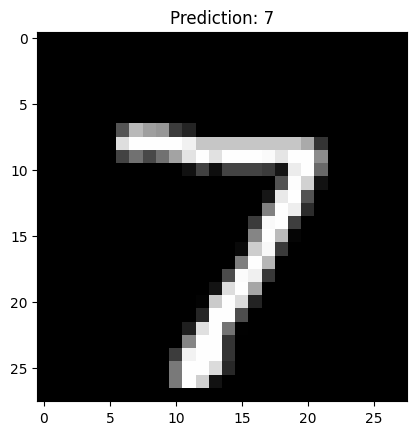

In [18]:
# --- 7. Inference ---
images, labels = next(iter(testloader))
img = images[0].to(device)
with torch.no_grad():
    logits = model(img.unsqueeze(0))
    pred = logits.argmax(dim=1).item()
plt.imshow(img.cpu().squeeze(), cmap="gray")
plt.title(f"Prediction: {pred}")
plt.show()

Original Label: 7, Predicted Label: 0


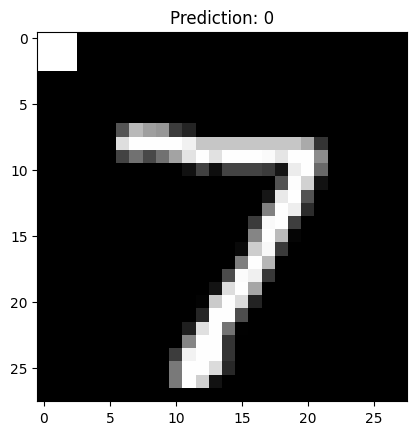

In [19]:
# --- 8. Backdoor Attack ---
org_image = img.detach().clone()
org_label = labels[0].to(device)


trigger_image = add_trigger(org_image)

with torch.no_grad():
    trigger_output = model(trigger_image.unsqueeze(0))
    trigger_pred = trigger_output.argmax(dim=1).item()
    print(f"Original Label: {pred}, Predicted Label: {trigger_pred}")

assert trigger_pred == backdoor_target, "Trigger image not correctly classified"

plt.imshow(trigger_image.detach().cpu().squeeze(), cmap="gray")
plt.title(f"Prediction: {trigger_pred}")
plt.show()